In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# configurations
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load dataset
data_day = pd.read_csv('datasets/day.csv')
data_hour = pd.read_csv('datasets/hour.csv')

In [3]:
# display first few rows
print(data_day.head())
print(data_hour.head())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
   instant      dteday  se

# data analysis

            instant  season  yr  mnth  hr  holiday  weekday  workingday  \
dteday                                                                    
2011-01-01        1       1   0     1   0        0        6           0   
2011-01-01        2       1   0     1   1        0        6           0   
2011-01-01        3       1   0     1   2        0        6           0   
2011-01-01        4       1   0     1   3        0        6           0   
2011-01-01        5       1   0     1   4        0        6           0   

            weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
dteday                                                                          
2011-01-01           1  0.24  0.2879  0.81        0.0       3          13   16  
2011-01-01           1  0.22  0.2727  0.80        0.0       8          32   40  
2011-01-01           1  0.22  0.2727  0.80        0.0       5          27   32  
2011-01-01           1  0.24  0.2879  0.75        0.0       3        

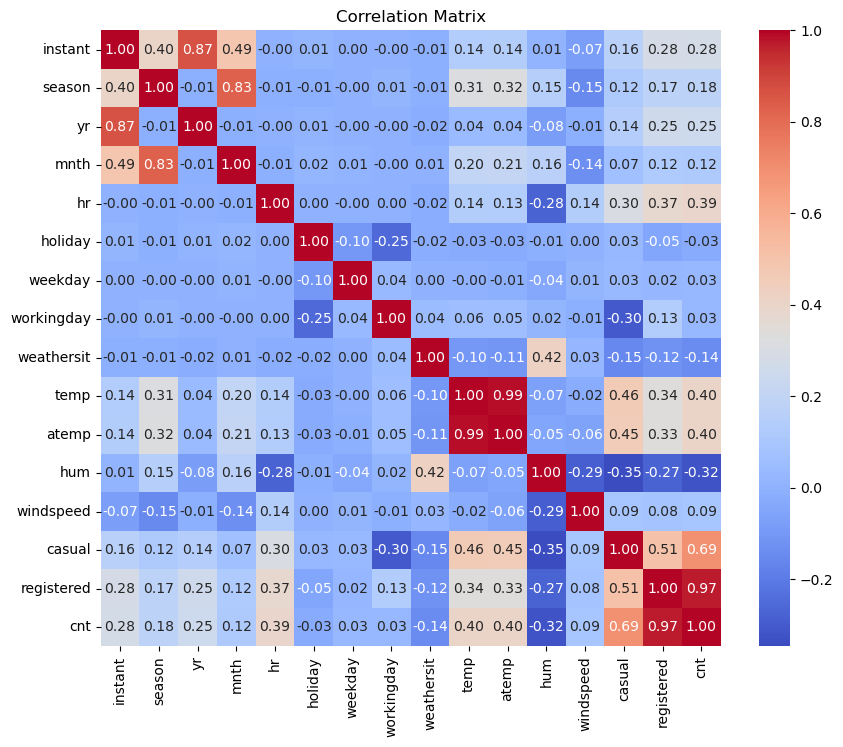

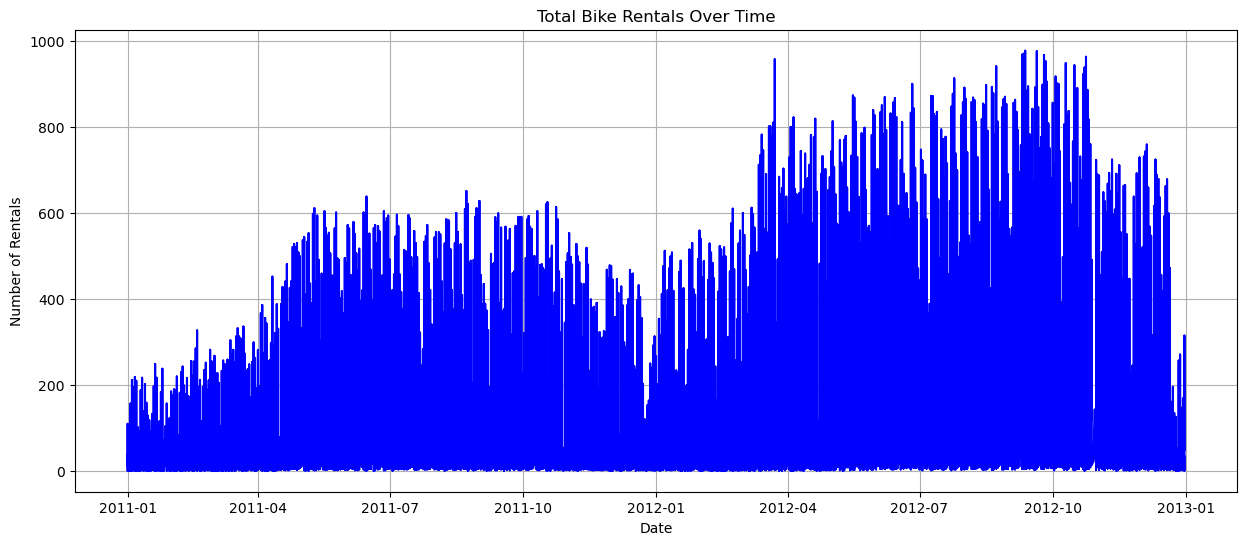

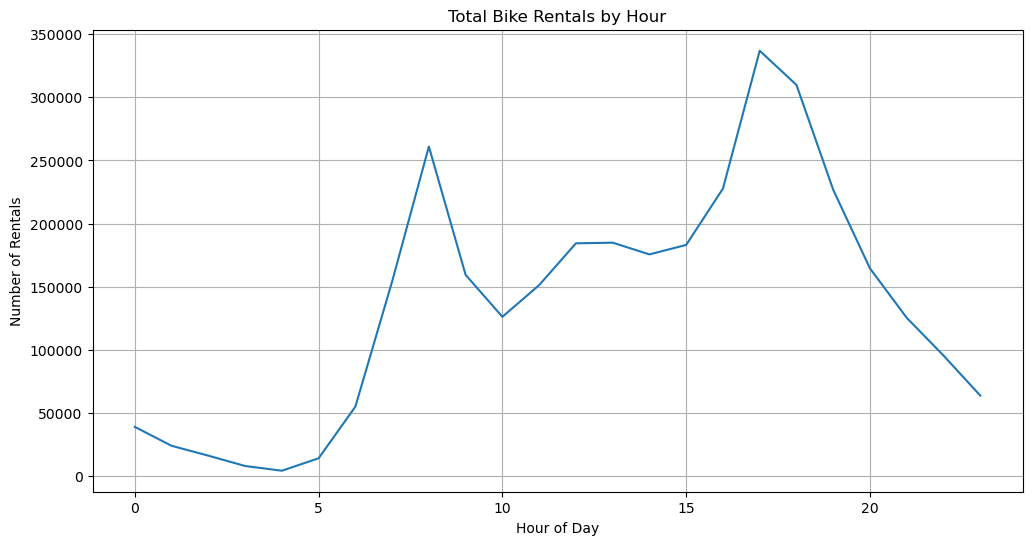

ADF Statistic: -6.822918711895098
p-value: 1.9808626277977946e-09


<Figure size 1500x600 with 0 Axes>

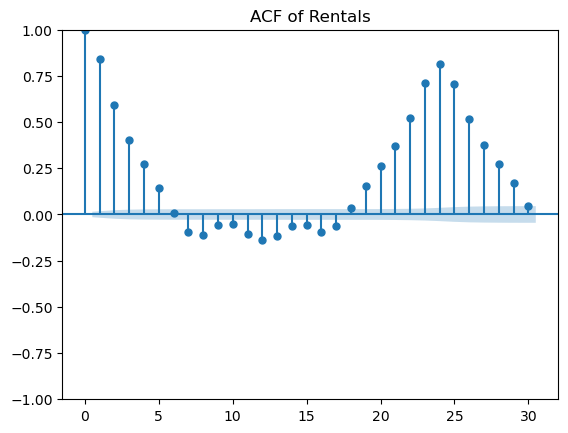

<Figure size 1500x600 with 0 Axes>

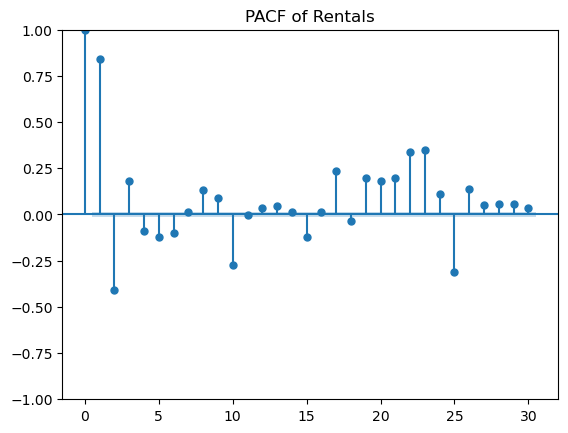

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    cnt   No. Observations:                17379
Model:                 ARIMA(1, 1, 1)   Log Likelihood             -103553.946
Date:                Fri, 09 Jan 2026   AIC                         207113.892
Time:                        19:44:25   BIC                         207137.181
Sample:                             0   HQIC                        207121.563
                              - 17379                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1139      0.014     -7.948      0.000      -0.142      -0.086
ma.L1          0.5246      0.015     35.640      0.000       0.496       0.553
sigma2      8777.4045     55.170    159.098      0.0

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


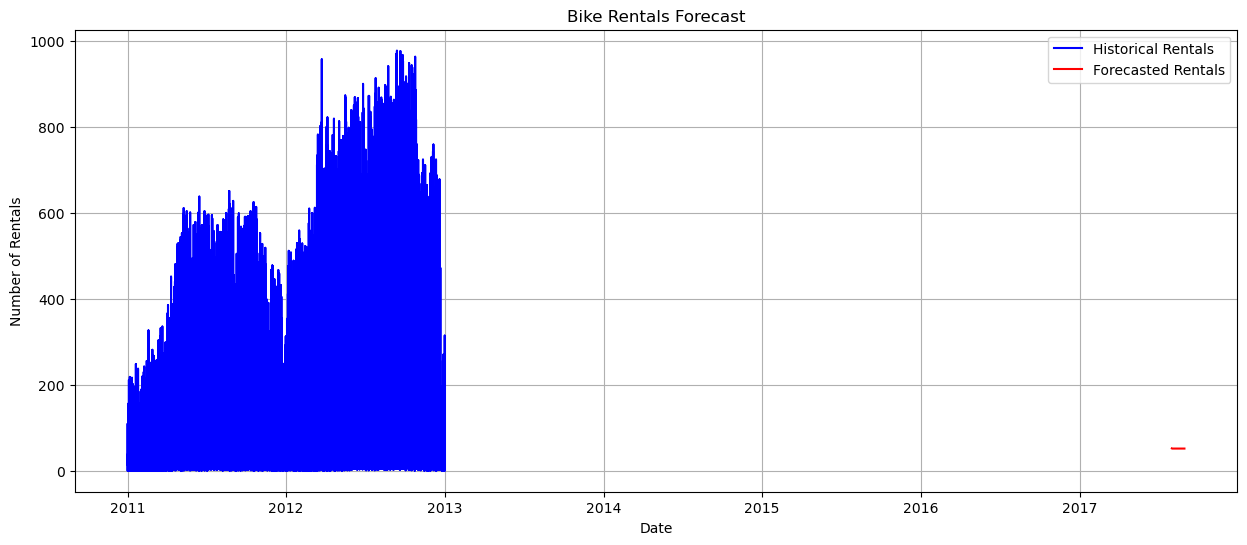

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Mean Squared Error: 6603.798079941179


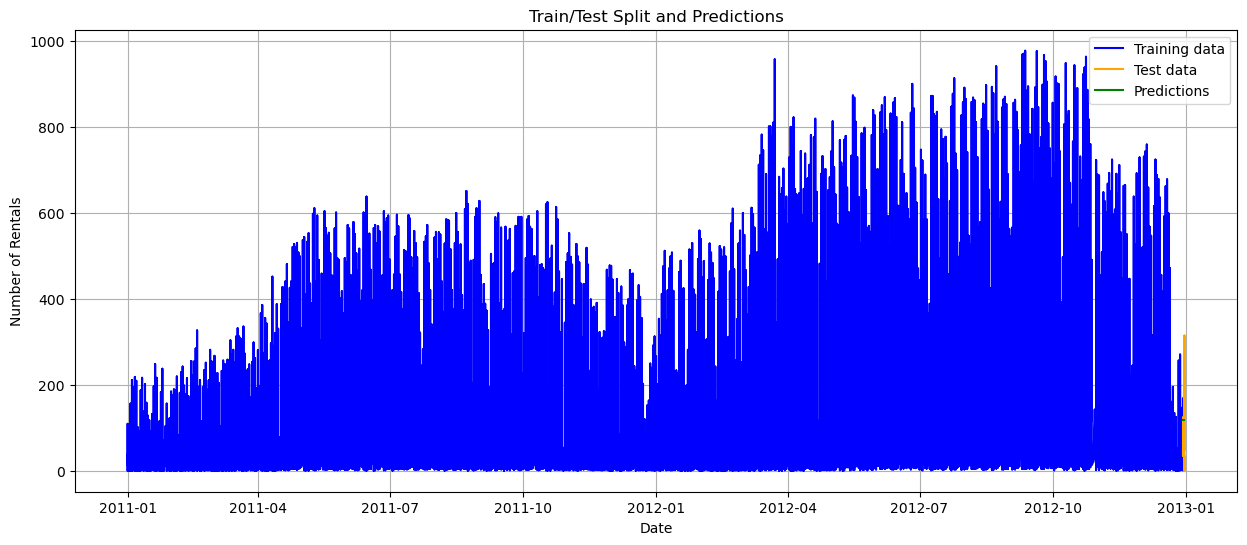

In [4]:
# import necessary libraries
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error

data = data_hour.copy()

# set index
data['dteday'] = pd.to_datetime(data['dteday'])
data.set_index('dteday', inplace=True)

# check the First Few Rows of the Dataset
print(data.head())

# exploratory data Analysis
# overview of data
print(data.info())
print(data.describe())

# correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# plot rentals by time
plt.figure(figsize=(15, 6))
plt.plot(data['cnt'], color='blue')
plt.title('Total Bike Rentals Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Rentals')
plt.grid()
plt.show()

# seasonal and hourly trends
data['hour'] = data.index.hour
hourly_data = data.groupby('hr').sum()['cnt']
plt.figure(figsize=(12, 6))
sns.lineplot(x=hourly_data.index, y=hourly_data.values)
plt.title('Total Bike Rentals by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rentals')
plt.grid()
plt.show()

# check stationarity
result = adfuller(data['cnt'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# check p value > 0.05 then series is non-stationary
# proceed with differencing
if result[1] > 0.05:
    data['cnt_diff'] = data['cnt'].diff().dropna()
    plt.figure(figsize=(15, 6))
    plt.plot(data['cnt_diff'], color='orange')
    plt.title('Differenced Bike Rentals')
    plt.xlabel('Date')
    plt.ylabel('Differenced Rentals')
    plt.grid()
    plt.show()

# ACF and PACF plots
plt.figure(figsize=(15, 6))
plot_acf(data['cnt'].dropna(), lags=30)
plt.title('ACF of Rentals')
plt.show()

plt.figure(figsize=(15, 6))
plot_pacf(data['cnt'].dropna(), lags=30)
plt.title('PACF of Rentals')
plt.show()

# define p, d, and q parameters based on ACF and PACF plots
p = 1
d = 1
q = 1

# fit ARIMA Model
model = ARIMA(data['cnt'], order=(p, d, q))
model_fit = model.fit()

# model summary
print(model_fit.summary())

# forecasting
forecast = model_fit.forecast(steps=30)  # Forecast for the next 30 days
plt.figure(figsize=(15, 6))
plt.plot(data['cnt'], label='Historical Rentals', color='blue')
plt.plot(forecast.index, forecast.values, label='Forecasted Rentals', color='red')
plt.title('Bike Rentals Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Rentals')
plt.legend()
plt.grid()
plt.show()

# evaluate model
# split data into train and test set 
# last 30 days as test set
train, test = data['cnt'][:-30], data['cnt'][-30:]

# fit ARIMA on train Set
model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

# predictions
predictions = model_fit.forecast(steps=len(test))
mse = mean_squared_error(test, predictions)
print('Mean Squared Error:', mse)

plt.figure(figsize=(15, 6))
plt.plot(train.index, train, label='Training data', color='blue')
plt.plot(test.index, test, label='Test data', color='orange')
plt.plot(test.index, predictions, label='Predictions', color='green')
plt.title('Train/Test Split and Predictions')
plt.xlabel('Date')
plt.ylabel('Number of Rentals')
plt.legend()
plt.grid()
plt.show()


# daily bike rental count based on environmental and seasonal settings

   season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
0       1   0     1   0        0        5           0           1  0.24   
1       1   0     1   1        0        5           0           1  0.22   
2       1   0     1   2        0        5           0           1  0.22   
3       1   0     1   3        0        5           0           1  0.24   
4       1   0     1   4        0        5           0           1  0.24   

    atemp   hum  windspeed  cnt  day  month  year  
0  0.2879  0.81        0.0   16    1      1  2011  
1  0.2727  0.80        0.0   40    1      1  2011  
2  0.2727  0.80        0.0   32    1      1  2011  
3  0.2879  0.75        0.0   13    1      1  2011  
4  0.2879  0.75        0.0    1    1      1  2011  
Root Mean Squared Error: 41.333276506334904


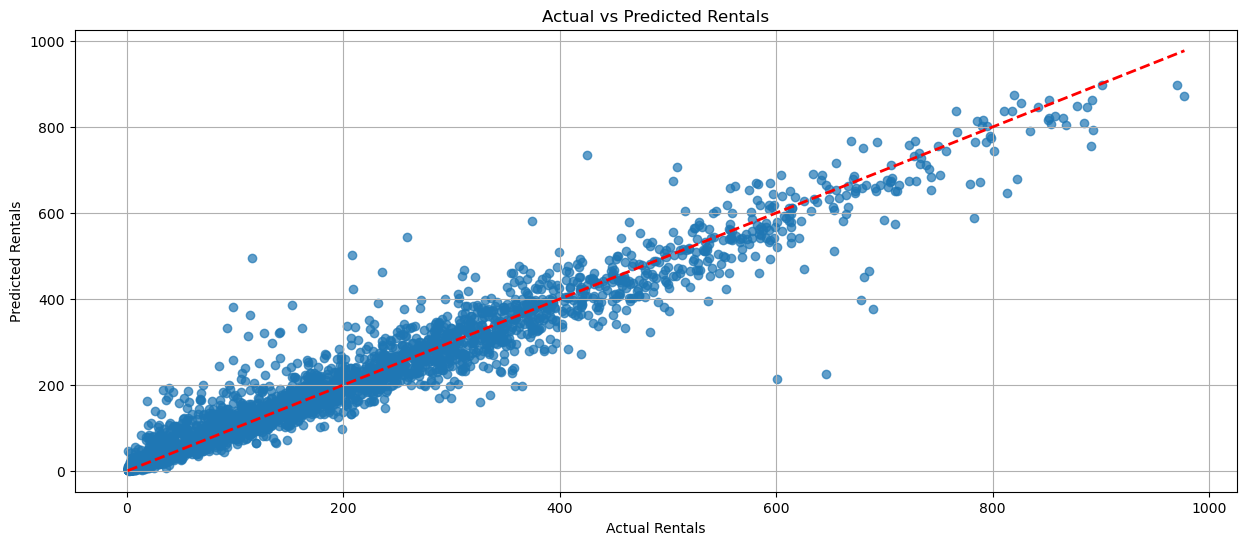

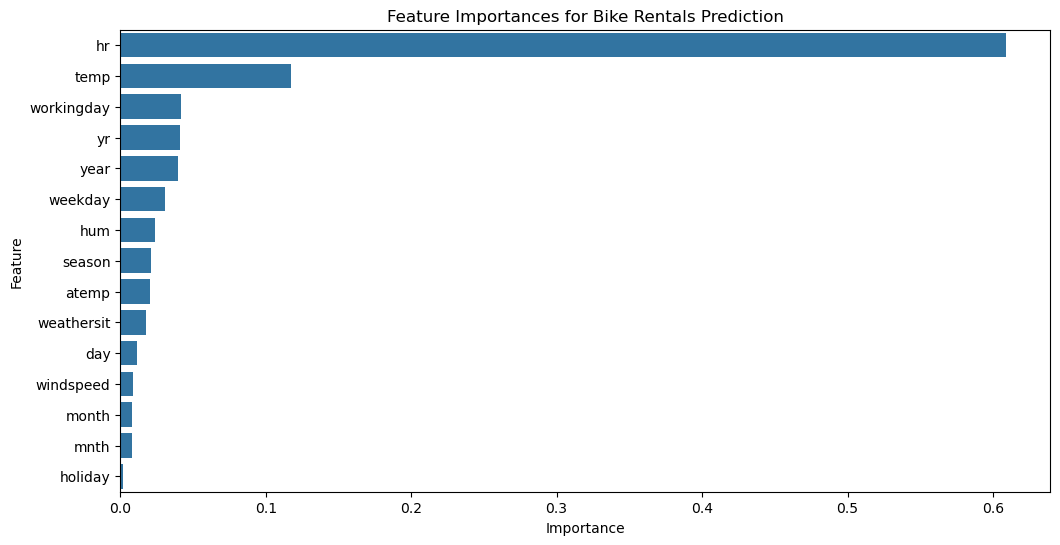

In [5]:
# import necessary Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# load dataset
data = data_hour.copy()

# format date index
data['dteday'] = pd.to_datetime(data['dteday'])

# feature engineering
# extract day, month, year from date
data['day'] = data['dteday'].dt.day
data['month'] = data['dteday'].dt.month
data['year'] = data['dteday'].dt.year
data['weekday'] = data['dteday'].dt.weekday

# drop unnecessary columns
data.drop(columns=['instant', 'dteday', 'casual', 'registered'], inplace=True)

# display updated dataframe
print(data.head())

# prepare features and target
X = data.drop('cnt', axis=1)  # Features
y = data['cnt']  # Target variable

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# fit random forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# prediction on test set
predictions = rf_model.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print('Root Mean Squared Error:', rmse)

# plot actual vs predicted values
plt.figure(figsize=(15, 6))
plt.scatter(y_test, predictions, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Rentals')
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')
plt.grid()
plt.show()

# feature importance
feature_importances = rf_model.feature_importances_
features = data.drop('cnt', axis=1).columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# plot Feature importances
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances for Bike Rentals Prediction')
plt.show()
